# Task 1: Dataset Exploration

In [ ]:
import pandas as pd

# Feature names
features = ['Variance', 'Skewness', 'Curtosis', 'Entropy', 'Class']

# Load the CSV
df = pd.read_csv('datasets/data_banknote_authentication.txt', names=features, header=None)

# Display first 5 samples
df.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [ ]:
# Print dataset dimensions
print('Dataset dimensions:', df.shape)

# Identify missing values in data
print(df.isnull().sum())

Dataset dimensions: (1372, 5)
Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64


In [ ]:
# Display descriptive statistics
df.describe()

,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


# Task 2: Exploratory Data Analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

# Set all text weights and sizes to 14 Bold globally
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'

# Ensure individual components inherit the bold styling and size
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['figure.titleweight'] = 'bold'

# Apply bold to axis tick numbers
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

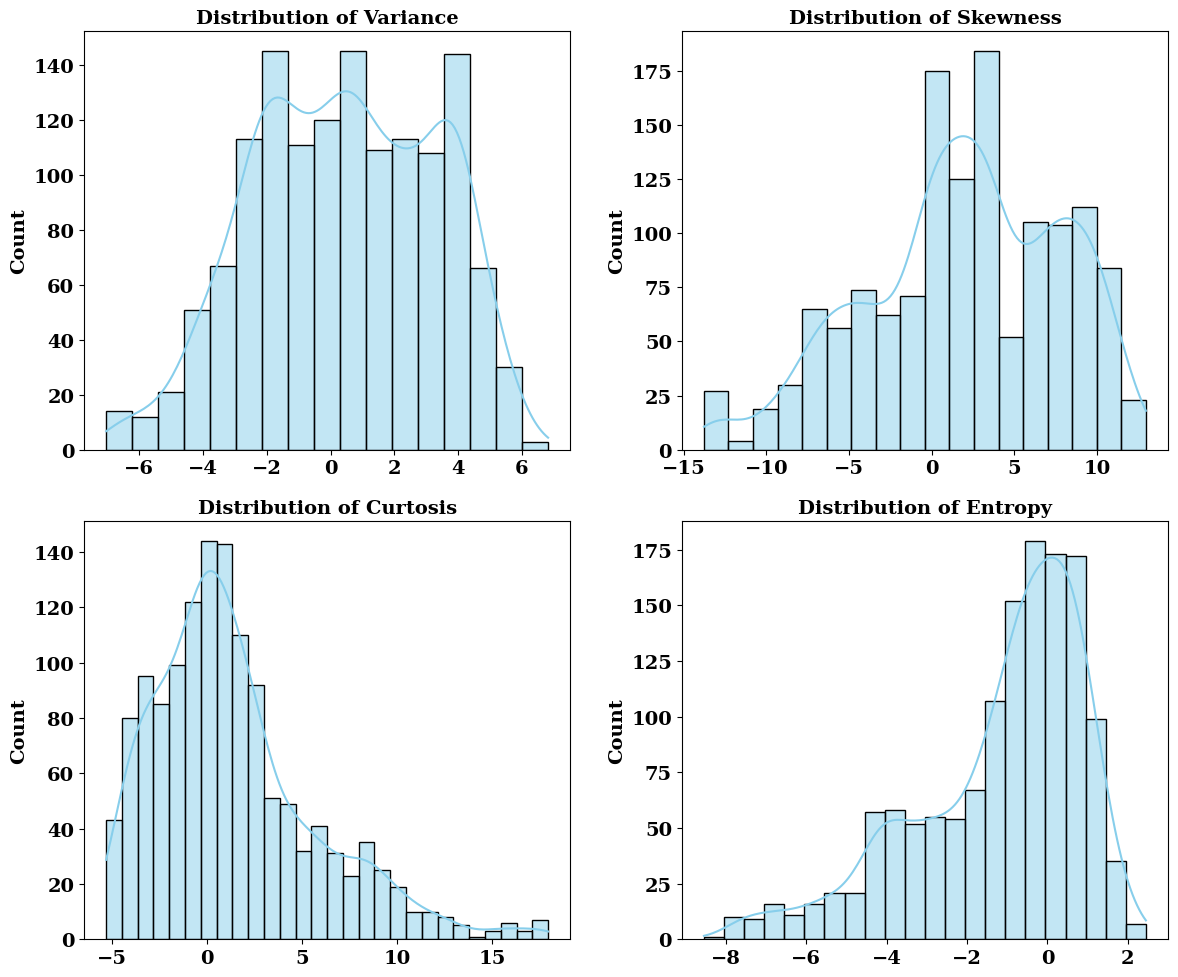

In [ ]:
# Create subplots for histograms
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(features[:-1]):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')

plt.savefig('banknote_histograms.eps', format='eps', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()

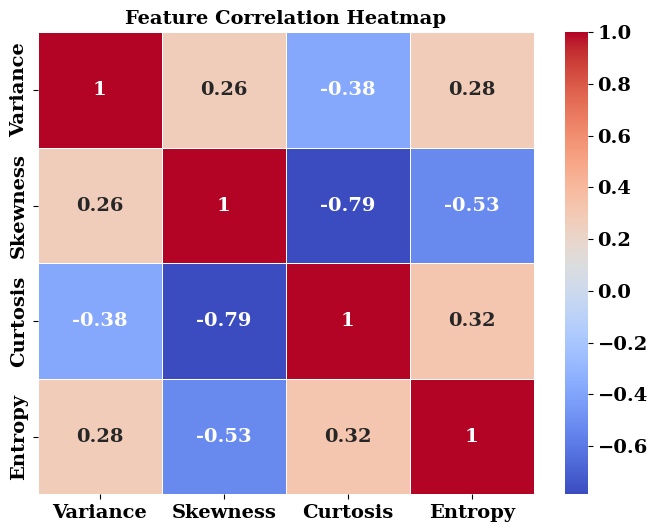

In [ ]:
plt.figure(figsize=(8, 6))

# Calculate the correlation matrix
corr_matrix = df[['Variance', 'Skewness', 'Curtosis', 'Entropy']].corr()

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)

plt.title('Feature Correlation Heatmap')

plt.savefig('banknote_heatmap.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

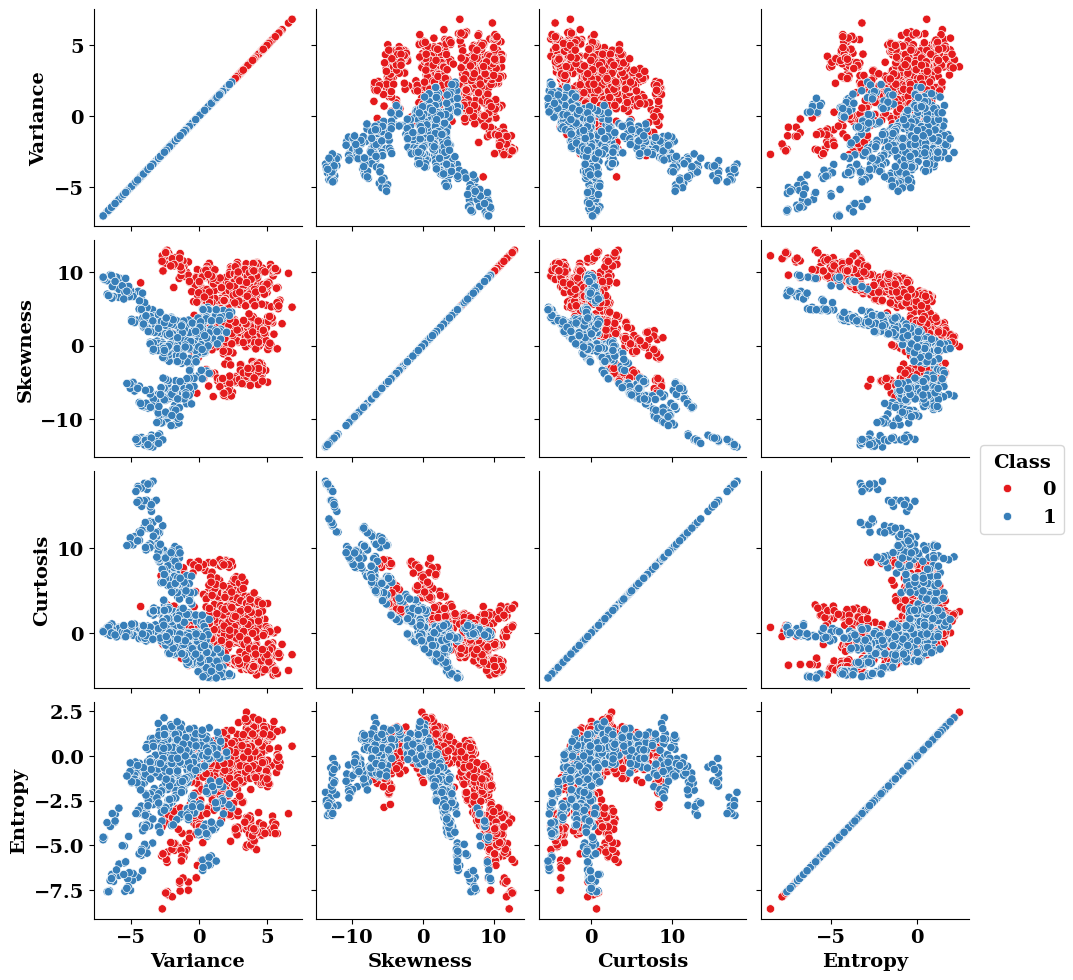

In [ ]:
# Plot pairwise scatterplots
g = sns.pairplot(df, vars=['Variance', 'Skewness', 'Curtosis', 'Entropy'], hue='Class', palette='Set1', diag_kind=None)

# 2. Add the bordered box around the legend
legend = g._legend
legend.set_frame_on(True)
plt.title('')

plt.savefig('banknote_pairplots.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

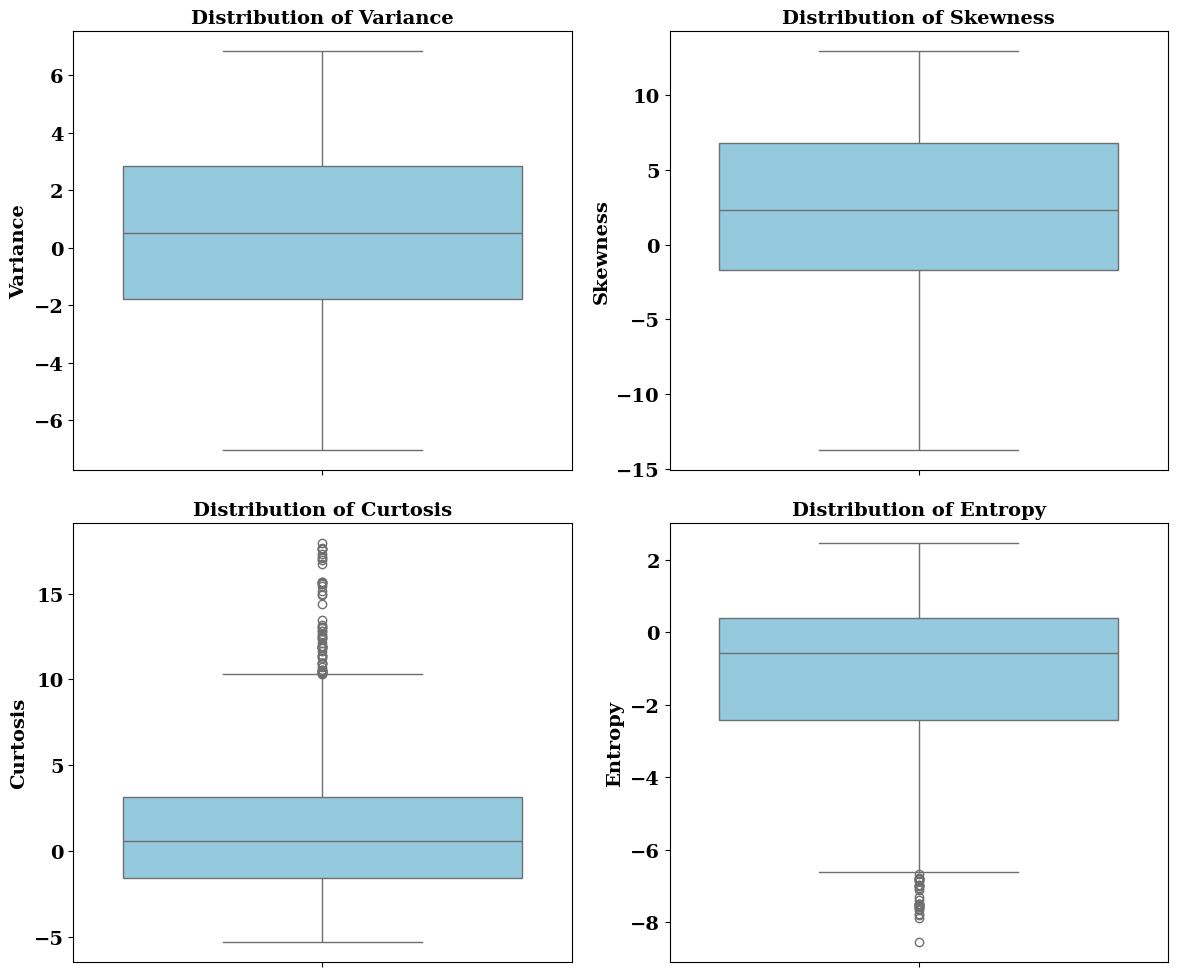

In [ ]:
# Create subplots for boxplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(features[:-1]):
    sns.boxplot(df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')

plt.savefig('banknote_boxplots.eps', format='eps', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()

# Task 3: Data Preprocessing

In [ ]:
# Separate features from target
X = df.drop(columns=['Class'])
y = df['Class']

# Apply normalization (min-max scaling)
X = (X - X.min()) / (X.max() - X.min())

In [ ]:
from sklearn.model_selection import train_test_split

# Make a 80, 40 split of the training data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Task 4: Perceptron Implementation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class SLPerceptron:
    # Constructor initialization
    def __init__(self, learning_rate=0.01, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.w = None
        self.b = None

    # Activation function
    def _step_activation(self, z):
        return np.where(z >= 0, 1, 0)

    # Model prediction
    def predict(self, X):
        z = np.dot(X, self.w) + self.b
        return self._step_activation(z)

    # Helper function to render and save subplots per epoch
    def _plot_and_save_epoch_grid(self, X, y, title, snapshots):
        num_plots = len(snapshots)
        fig, axes = plt.subplots(1, num_plots, figsize=(4 * num_plots, 4))

        if num_plots == 1:
            axes = [axes]

        for idx, snap in enumerate(snapshots):
            ax = axes[idx]
            w_snap, b_snap, epoch_num = snap['w'], snap['b'], snap['epoch']

            # Plot samples
            for i in range(len(X)):
                color = 'blue' if y[i] == 1 else 'red'
                marker = 'o' if y[i] == 1 else 's'
                ax.scatter(X[i][0], X[i][1] if X.shape[1] > 1 else 0, color=color, marker=marker, s=80)

            # 2D Decision Boundary (AND, OR, XOR)
            if X.shape[1] == 2:
                x1_vals = np.array([-0.5, 1.5])
                if w_snap[1] != 0:
                    x2_vals = -(w_snap[0] * x1_vals + b_snap) / w_snap[1]
                    ax.plot(x1_vals, x2_vals, 'k--', label='Boundary')
                elif w_snap[0] != 0:
                    ax.axvline(x=-b_snap / w_snap[0], color='k', linestyle='--')
                ax.set_ylim(-0.5, 1.5)
                ax.set_ylabel('Input X2')

            # 1D Decision Boundary (NOT)
            elif X.shape[1] == 1:
                if w_snap[0] != 0:
                    ax.axvline(x=-b_snap / w_snap[0], color='k', linestyle='--', label='Boundary')
                ax.set_ylim(-0.5, 0.5)

            ax.set_xlim(-0.5, 1.5)
            ax.set_xlabel('Input X1')
            ax.set_title(f"Epoch {epoch_num}\nw: {np.round(w_snap, 2)}, b: {round(b_snap, 2)}")
            ax.grid(True)

        fig.suptitle(f"{title} - Decision Boundaries Per Epoch", fontsize=14, y=1.05)
        plt.tight_layout()

        # Save as 600 DPI EPS vector file
        filename = f"{title.replace(' ', '_')}_epochs.eps"
        plt.savefig(filename, format='eps', dpi=600, bbox_inches='tight')

        plt.show()
        plt.close(fig)

    # Model training
    def fit(self, X, y, title="Gate", plot_boundary=False, verbose_per_update=False):
        X = np.asarray(X)
        y = np.asarray(y)
        n_features = X.shape[1]

        # Tracking variables
        self.weights_per_update_ = []
        self.biases_per_update_ = []
        self.weights_ = []
        self.biases_ = []
        self.errors_ = []
        epoch_snapshots = []

        self.w = np.zeros(n_features) # Weight initialization
        self.b = 0.0 # Bias initialization

        update_count = 0

        # FIXED: Loop runs for the FULL number of requested epochs now
        for i in range(self.epochs):
            errors = 0
            for j, x in enumerate(X):
                y_true = y[j]
                y_pred = self.predict(x)
                error = y_true - y_pred

                if error == 0:
                    continue

                errors += 1
                update_count += 1

                # Weight update rule
                self.w += self.learning_rate * error * x
                self.b += self.learning_rate * error

                # Track per-update weights
                self.weights_per_update_.append(self.w.copy())
                self.biases_per_update_.append(self.b)

                if verbose_per_update:
                    print(f"  Update #{update_count} (Epoch {i+1}) | Input: {x} | w: {np.round(self.w, 3)} | b: {round(self.b, 3)}")

            self.errors_.append(errors)

            # Track per-epoch weights
            self.weights_.append(self.w.copy())
            self.biases_.append(self.b)
            epoch_snapshots.append({'epoch': i + 1, 'w': self.w.copy(), 'b': self.b})

            print(f"Epoch: {i + 1} | Misclassified Samples: {errors} | Weights: {np.round(self.w, 2)} | Bias: {np.round(self.b, 2)}")

            if errors == 0:
                print(f"--> Converged successfully in {i + 1} epochs!\n")
                break

        # FIXED: Only pass the first 4 epoch snapshots to the subplot grid so it doesn't break
        if plot_boundary and len(epoch_snapshots) > 0:
            self._plot_and_save_epoch_grid(X, y, title, epoch_snapshots[:4])

        return self

# Task 5: Model Training

In [ ]:
# 1. Initialize and train model
model = SLPerceptron(learning_rate=0.01, epochs=35)
model.fit(X_train, y_train)

# 2. Generate predictions
y_pred = model.predict(X_test)

Epoch: 1 | Misclassified Samples: 166 | Weights: [-0.07 -0.04 -0.05  0.02] | Bias: 0.08
Epoch: 2 | Misclassified Samples: 88 | Weights: [-0.08 -0.06 -0.08  0.01] | Bias: 0.1
Epoch: 3 | Misclassified Samples: 57 | Weights: [-0.09 -0.07 -0.1   0.02] | Bias: 0.11
Epoch: 4 | Misclassified Samples: 51 | Weights: [-0.1  -0.08 -0.09  0.01] | Bias: 0.12
Epoch: 5 | Misclassified Samples: 47 | Weights: [-0.1  -0.09 -0.1   0.01] | Bias: 0.13
Epoch: 6 | Misclassified Samples: 45 | Weights: [-0.11 -0.09 -0.1   0.  ] | Bias: 0.14
Epoch: 7 | Misclassified Samples: 48 | Weights: [-0.11 -0.1  -0.11  0.01] | Bias: 0.14
Epoch: 8 | Misclassified Samples: 32 | Weights: [-0.12 -0.1  -0.12  0.01] | Bias: 0.14
Epoch: 9 | Misclassified Samples: 19 | Weights: [-0.12 -0.1  -0.12  0.01] | Bias: 0.15
Epoch: 10 | Misclassified Samples: 40 | Weights: [-0.12 -0.11 -0.12  0.01] | Bias: 0.15
Epoch: 11 | Misclassified Samples: 35 | Weights: [-0.12 -0.11 -0.12  0.01] | Bias: 0.16
Epoch: 12 | Misclassified Samples: 28 | W

# Task 6: Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Compute performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("Confusion Matrix:\n", cm)

Accuracy:  0.9927
Precision: 1.0000
Recall:    0.9843
F1-Score:  0.9921
Confusion Matrix:
 [[148   0]
 [  2 125]]


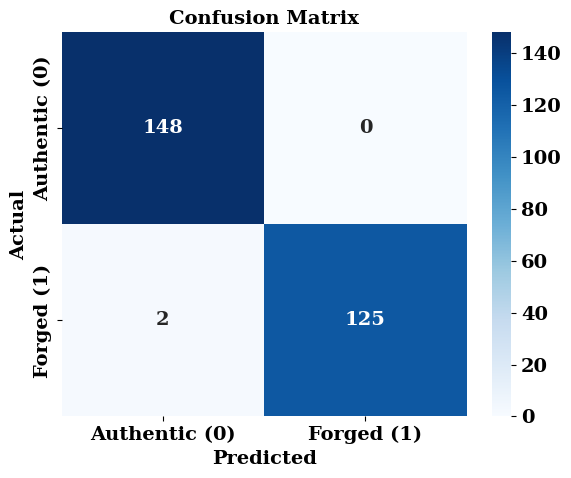

In [ ]:
# Plot confusion matrix
class_names = ['Authentic (0)', 'Forged (1)']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.savefig('confusion_matrix.eps', format='eps', dpi=600, bbox_inches='tight')

plt.tight_layout()
plt.show()

# Additional Plots and Tasks:

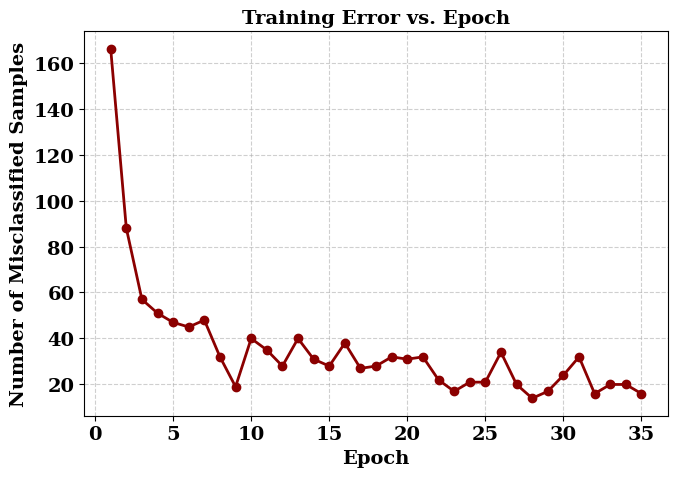

In [ ]:
# Training error vs epochs plot
plt.figure(figsize=(7, 5))

plt.plot(range(1, len(model.errors_) + 1), model.errors_,
         color='darkred', marker='o', linewidth=2, markersize=6)

plt.title('Training Error vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Number of Misclassified Samples')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('error_vs_epoch.eps', format='eps', dpi=600, bbox_inches='tight')

plt.show()

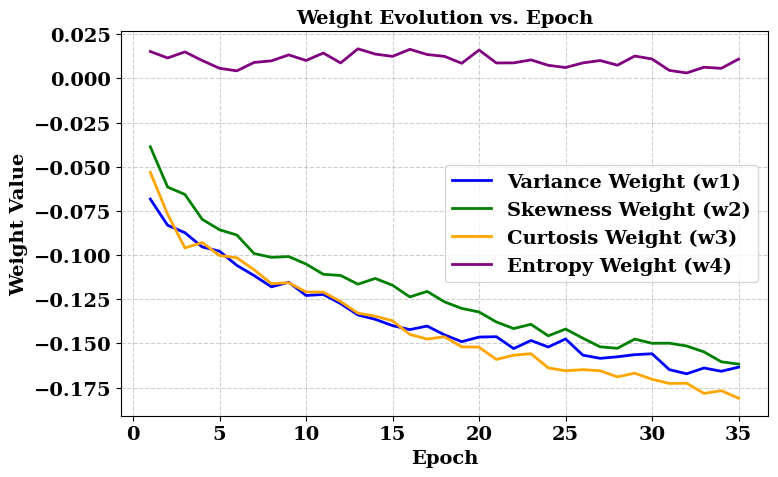

In [ ]:
# Weight evolution plot
weights_matrix = np.array(model.weights_)

plt.figure(figsize=(8, 5))

feature_labels = ['Variance Weight (w1)', 'Skewness Weight (w2)', 'Curtosis Weight (w3)', 'Entropy Weight (w4)']
colors = ['blue', 'green', 'orange', 'purple']

for i in range(4):
    plt.plot(range(1, len(weights_matrix) + 1), weights_matrix[:, i],
             label=feature_labels[i], color=colors[i], linewidth=2)

plt.title('Weight Evolution vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Weight Value')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('parameter_evolution.eps', format='eps', dpi=600, bbox_inches='tight')

plt.show()

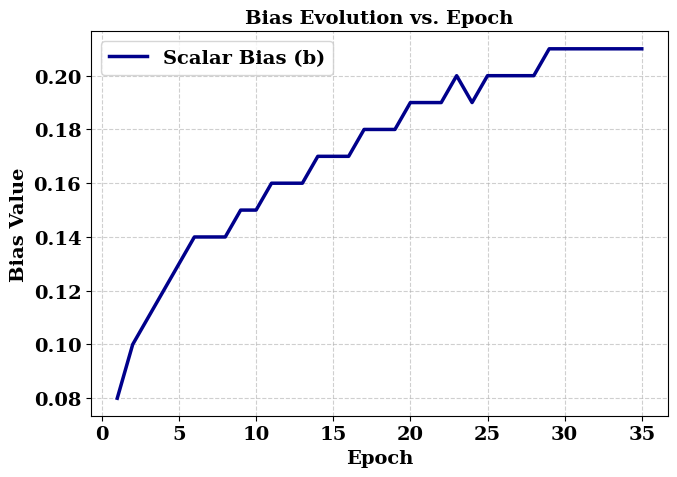

In [ ]:
# Bias evolution plot
plt.figure(figsize=(7, 5))

plt.plot(range(1, len(model.biases_) + 1), model.biases_,
         color='darkblue', linewidth=2.5, label='Scalar Bias (b)')

plt.title('Bias Evolution vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Bias Value')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('bias_evolution.eps', format='eps', dpi=600, bbox_inches='tight')

plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:11: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_3872/238207126.py:11: SyntaxWarning: invalid escape sequence '\e'
  label=f'Learning Rate ($\eta$ = {lr})', color=color, linewidth=2)


Epoch: 1 | Misclassified Samples: 166 | Weights: [-0.01 -0.   -0.01  0.  ] | Bias: 0.01
Epoch: 2 | Misclassified Samples: 88 | Weights: [-0.01 -0.01 -0.01  0.  ] | Bias: 0.01
Epoch: 3 | Misclassified Samples: 57 | Weights: [-0.01 -0.01 -0.01  0.  ] | Bias: 0.01
Epoch: 4 | Misclassified Samples: 51 | Weights: [-0.01 -0.01 -0.01  0.  ] | Bias: 0.01
Epoch: 5 | Misclassified Samples: 47 | Weights: [-0.01 -0.01 -0.01  0.  ] | Bias: 0.01
Epoch: 6 | Misclassified Samples: 45 | Weights: [-0.01 -0.01 -0.01  0.  ] | Bias: 0.01
Epoch: 7 | Misclassified Samples: 48 | Weights: [-0.01 -0.01 -0.01  0.  ] | Bias: 0.01
Epoch: 8 | Misclassified Samples: 32 | Weights: [-0.01 -0.01 -0.01  0.  ] | Bias: 0.01
Epoch: 9 | Misclassified Samples: 19 | Weights: [-0.01 -0.01 -0.01  0.  ] | Bias: 0.02
Epoch: 10 | Misclassified Samples: 40 | Weights: [-0.01 -0.01 -0.01  0.  ] | Bias: 0.02
Epoch: 11 | Misclassified Samples: 35 | Weights: [-0.01 -0.01 -0.01  0.  ] | Bias: 0.02
Epoch: 12 | Misclassified Samples: 28 | 

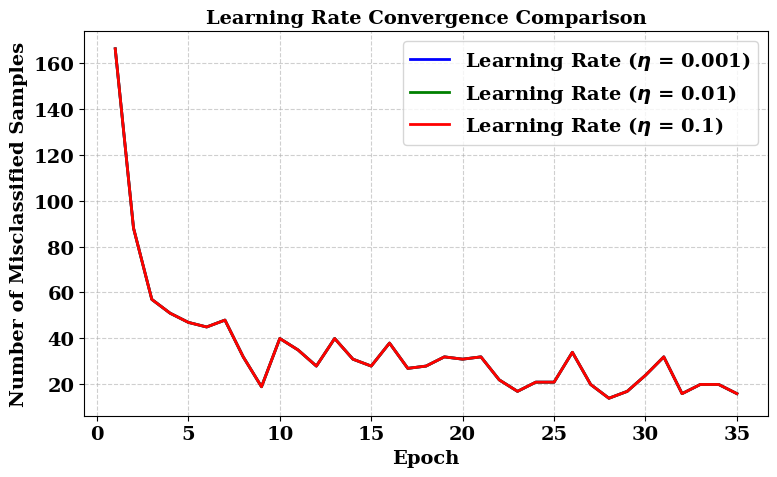

In [ ]:
learning_rates = [0.001, 0.01, 0.1]
colors = ['blue', 'green', 'red']

plt.figure(figsize=(8, 5))

for lr, color in zip(learning_rates, colors):
    model_lr = SLPerceptron(learning_rate=lr, epochs=35)
    model_lr.fit(X_train, y_train)

    plt.plot(range(1, len(model_lr.errors_) + 1), model_lr.errors_,
             label=f'Learning Rate ($\eta$ = {lr})', color=color, linewidth=2)

plt.title('Learning Rate Convergence Comparison')
plt.xlabel('Epoch')
plt.ylabel('Number of Misclassified Samples')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('learning_rate_comparison.eps', format='eps', dpi=600, bbox_inches='tight')

plt.show()

Epoch: 1 | Misclassified Samples: 238 | Weights: [-0.07 -0.02] | Bias: 0.06
Epoch: 2 | Misclassified Samples: 187 | Weights: [-0.08 -0.03] | Bias: 0.07
Epoch: 3 | Misclassified Samples: 177 | Weights: [-0.08 -0.04] | Bias: 0.08
Epoch: 4 | Misclassified Samples: 174 | Weights: [-0.08 -0.03] | Bias: 0.08
Epoch: 5 | Misclassified Samples: 180 | Weights: [-0.08 -0.03] | Bias: 0.08
Epoch: 6 | Misclassified Samples: 176 | Weights: [-0.08 -0.03] | Bias: 0.08
Epoch: 7 | Misclassified Samples: 166 | Weights: [-0.07 -0.04] | Bias: 0.08
Epoch: 8 | Misclassified Samples: 178 | Weights: [-0.08 -0.03] | Bias: 0.08
Epoch: 9 | Misclassified Samples: 177 | Weights: [-0.08 -0.04] | Bias: 0.09
Epoch: 10 | Misclassified Samples: 178 | Weights: [-0.08 -0.04] | Bias: 0.09
Epoch: 11 | Misclassified Samples: 172 | Weights: [-0.08 -0.04] | Bias: 0.09
Epoch: 12 | Misclassified Samples: 176 | Weights: [-0.08 -0.04] | Bias: 0.09
Epoch: 13 | Misclassified Samples: 171 | Weights: [-0.09 -0.04] | Bias: 0.08
Epoch: 1

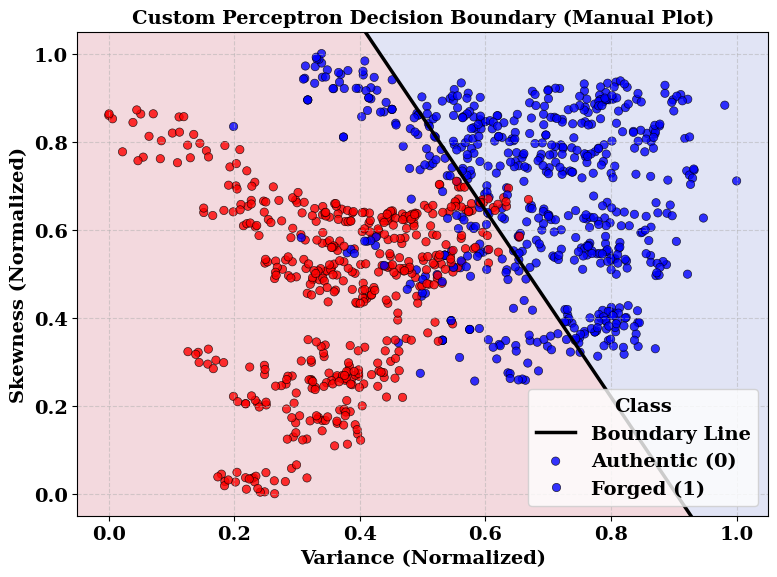

In [ ]:
feature_cols = ['Variance', 'Skewness']
X_train_2d = X_train[feature_cols]

my_perceptron = SLPerceptron(learning_rate=0.01, epochs=50)
my_perceptron.fit(X_train_2d, y_train)

w1, w2 = my_perceptron.w[0], my_perceptron.w[1]
b = my_perceptron.b

x1_values = np.linspace(X_train_2d['Variance'].min(), X_train_2d['Variance'].max(), 100)
x2_values = -(w1 / w2) * x1_values - (b / w2)

plt.figure(figsize=(8, 6))

plt.plot(x1_values, x2_values, color='black', linestyle='-', linewidth=2.5, label='Decision Boundary')

x_min, x_max = X_train_2d['Variance'].min() - 0.05, X_train_2d['Variance'].max() + 0.05
y_min, y_max = X_train_2d['Skewness'].min() - 0.05, X_train_2d['Skewness'].max() + 0.05
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_preds = my_perceptron.predict(grid_points).reshape(xx.shape)

plt.pcolormesh(xx, yy, grid_preds, cmap=plt.cm.coolwarm, alpha=0.15, shading='auto')

sns.scatterplot(
    x=X_train_2d['Variance'],
    y=X_train_2d['Skewness'],
    hue=y_train,
    palette={0: 'blue', 1: 'red'},
    alpha=0.8,
    edgecolor='k'
)

plt.title('Custom Perceptron Decision Boundary (Manual Plot)')
plt.xlabel('Variance (Normalized)')
plt.ylabel('Skewness (Normalized)')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.legend(title='Class', labels=['Boundary Line', 'Authentic (0)', 'Forged (1)'])
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('decision_boundary.eps', format='eps', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
# Try scikit-learn implementation.
from sklearn.linear_model import Perceptron

# 1. Initialize and train the model
model = Perceptron(eta0=0.01, max_iter=50)
model.fit(X_train, y_train)

# 2. Generate predictions
y_pred = model.predict(X_test)

In [ ]:
# Compute performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("Confusion Matrix:\n", cm)

Accuracy:  0.9418
Precision: 1.0000
Recall:    0.8740
F1-Score:  0.9328
Confusion Matrix:
 [[148   0]
 [ 16 111]]


1. AND GATE
Epoch: 1 | Misclassified Samples: 2 | Weights: [0.1 0.1] | Bias: 0.0
Epoch: 2 | Misclassified Samples: 3 | Weights: [0.2 0.1] | Bias: -0.1
Epoch: 3 | Misclassified Samples: 3 | Weights: [0.2 0.1] | Bias: -0.2
Epoch: 4 | Misclassified Samples: 0 | Weights: [0.2 0.1] | Bias: -0.2
--> Converged successfully in 4 epochs!



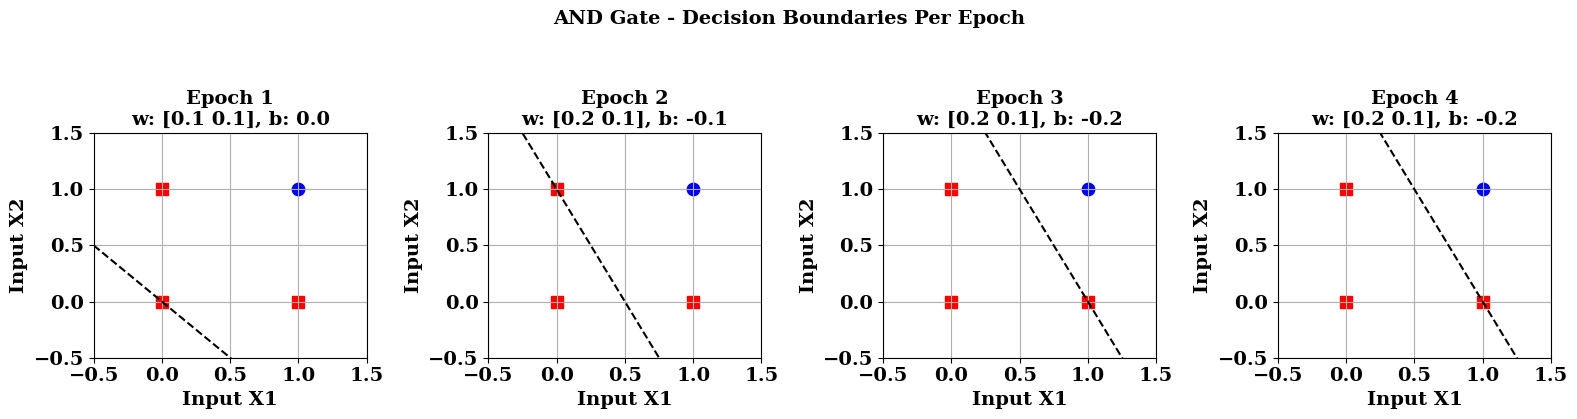

2. OR GATE
Epoch: 1 | Misclassified Samples: 2 | Weights: [0.  0.1] | Bias: 0.0
Epoch: 2 | Misclassified Samples: 2 | Weights: [0.1 0.1] | Bias: 0.0
Epoch: 3 | Misclassified Samples: 1 | Weights: [0.1 0.1] | Bias: -0.1
Epoch: 4 | Misclassified Samples: 0 | Weights: [0.1 0.1] | Bias: -0.1
--> Converged successfully in 4 epochs!



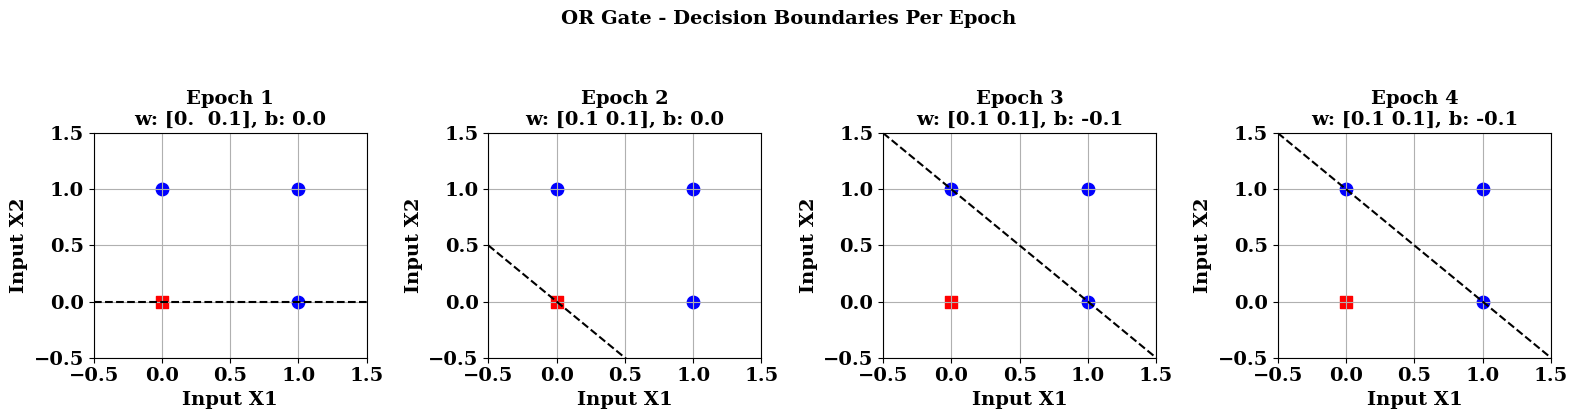

3. NOT GATE
Epoch: 1 | Misclassified Samples: 1 | Weights: [-0.1] | Bias: -0.1
Epoch: 2 | Misclassified Samples: 1 | Weights: [-0.1] | Bias: 0.0
Epoch: 3 | Misclassified Samples: 0 | Weights: [-0.1] | Bias: 0.0
--> Converged successfully in 3 epochs!



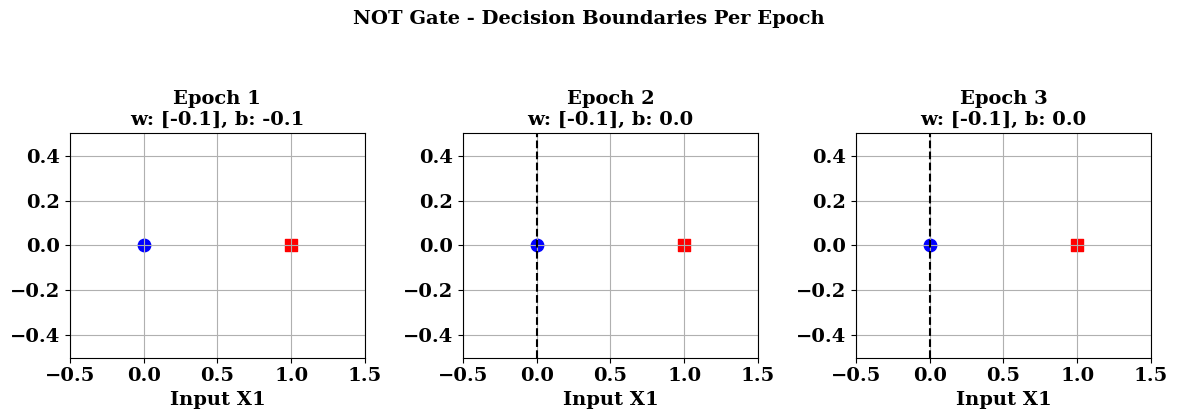

4. XOR GATE
Epoch: 1 | Misclassified Samples: 3 | Weights: [-0.1  0. ] | Bias: -0.1
Epoch: 2 | Misclassified Samples: 3 | Weights: [-0.1  0. ] | Bias: 0.0
Epoch: 3 | Misclassified Samples: 4 | Weights: [-0.1  0. ] | Bias: 0.0
Epoch: 4 | Misclassified Samples: 4 | Weights: [-0.1  0. ] | Bias: 0.0


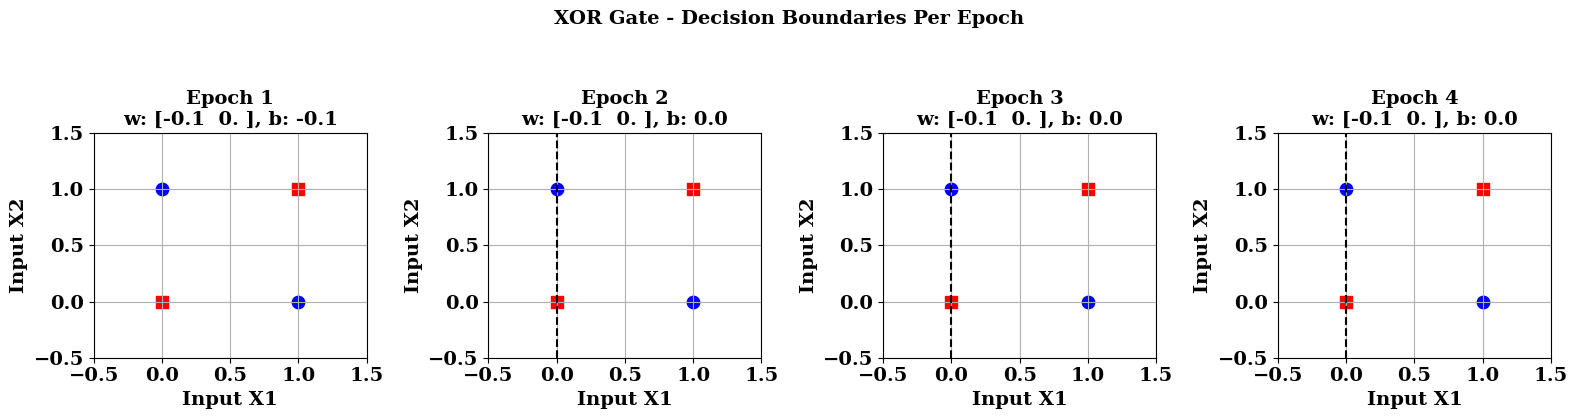

In [ ]:
import numpy as np

# ==========================================
# 1. Dataset Definitions
# ==========================================

# 2D Inputs for AND, OR, XOR
X_2D = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_and = np.array([0, 0, 0, 1])
y_or  = np.array([0, 1, 1, 1])
y_xor = np.array([0, 1, 1, 0])

# 1D Inputs for NOT Gate
X_1D = np.array([
    [0],
    [1]
])

y_not = np.array([1, 0])


# ==========================================
# 2. Execution and Plotting
# ==========================================

print("=" * 40)
print("1. AND GATE")
print("=" * 40)
model_and = SLPerceptron(learning_rate=0.1, epochs=4)
model_and.fit(X_2D, y_and, title="AND Gate", plot_boundary=True)

print("=" * 40)
print("2. OR GATE")
print("=" * 40)
model_or = SLPerceptron(learning_rate=0.1, epochs=4)
model_or.fit(X_2D, y_or, title="OR Gate", plot_boundary=True)

print("=" * 40)
print("3. NOT GATE")
print("=" * 40)
model_not = SLPerceptron(learning_rate=0.1, epochs=4)
model_not.fit(X_1D, y_not, title="NOT Gate", plot_boundary=True)

print("=" * 40)
print("4. XOR GATE")
print("=" * 40)
model_xor = SLPerceptron(learning_rate=0.1, epochs=4)
model_xor.fit(X_2D, y_xor, title="XOR Gate", plot_boundary=True)